

```
# Task 4: Email Spam Detection with Machine Learning

**Objective**: Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

**Dataset**: emails.csv (actual email spam dataset)

**Tech Stack**: Python, scikit-learn (TF-IDF, Naive Bayes, SVM), NLTK, pandas, matplotlib
```



In [8]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import re
from google.colab import files
import io
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

# Download stopwords if not already
nltk.download('stopwords', quiet=True)

# Initialize the stemmer (ADD THIS LINE - VERY IMPORTANT!)
stemmer = PorterStemmer()

In [9]:
# Step 2: Upload file
print("📁 Please upload 'emails.csv'")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

📁 Please upload 'emails.csv'


Saving emails.csv to emails (1).csv


In [10]:
# Step 3: Load the dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"✅ Data loaded! Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nColumns: {df.columns.tolist()}")

✅ Data loaded! Shape: (5728, 2)

First 5 rows:
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

Columns: ['text', 'spam']


In [11]:
# Step 4: Check class distribution
print(f"\n📊 Class distribution:")
print(df['spam'].value_counts())
print(f"\nSpam percentage: {df['spam'].value_counts(normalize=True)[1]*100:.2f}%")
print(f"Ham percentage: {df['spam'].value_counts(normalize=True)[0]*100:.2f}%")


📊 Class distribution:
spam
0    4360
1    1368
Name: count, dtype: int64

Spam percentage: 23.88%
Ham percentage: 76.12%


In [12]:
# Step 5: Check for null values
print(f"\nNull values:\n{df.isnull().sum()}")
df.dropna(inplace=True)


Null values:
text    0
spam    0
dtype: int64


In [13]:
# Step 6: Text preprocessing with STEMMING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    # Apply stemming to each word
    words = [stemmer.stem(word) for word in words]  # NOW stemmer is defined!
    return ' '.join(words)

print("\n🔄 Cleaning email text with stemming...")
df['clean_text'] = df['text'].apply(clean_text)

print(f"\n✅ Text preprocessing complete! (Stemming applied)")



🔄 Cleaning email text with stemming...

✅ Text preprocessing complete! (Stemming applied)


In [14]:
# Step 7: TF-IDF Vectorization (Feature Extraction)
print("\n🔄 Extracting features using TF-IDF Vectorizer...")

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['spam'].values

print(f"\n✅ Vectorization complete! Features: {X.shape[1]}")


🔄 Extracting features using TF-IDF Vectorizer...

✅ Vectorization complete! Features: 3000


In [15]:
# Step 8: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Training: {len(X_train)} emails")
print(f"✅ Test: {len(X_test)} emails")


✅ Training: 4582 emails
✅ Test: 1146 emails


In [16]:
# Step 9: Train multiple classifiers
print("\n🔄 Training Email Spam Detection Models...")

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

    print(f"\n📊 {name} Results:")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall: {rec:.4f}")
    print(f"   F1 Score: {f1:.4f}")


🔄 Training Email Spam Detection Models...

🔹 Training Multinomial Naive Bayes...

📊 Multinomial Naive Bayes Results:
   Accuracy: 0.9869
   Precision: 0.9758
   Recall: 0.9724
   F1 Score: 0.9741

🔹 Training Logistic Regression...

📊 Logistic Regression Results:
   Accuracy: 0.9791
   Precision: 0.9854
   Recall: 0.9310
   F1 Score: 0.9574

🔹 Training SVM...

📊 SVM Results:
   Accuracy: 0.9895
   Precision: 0.9894
   Recall: 0.9690
   F1 Score: 0.9791


In [17]:
# Step 10: Identify best model
best_model_name = max(results, key=lambda x: results[x]['F1'])
print(f"\n🏆 Best performing model: {best_model_name}")


🏆 Best performing model: SVM


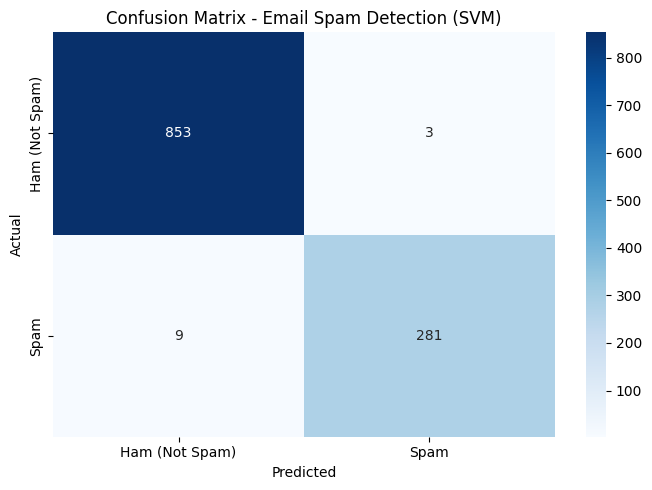

In [18]:
# Step 11: Confusion matrix for best model
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham (Not Spam)', 'Spam'],
            yticklabels=['Ham (Not Spam)', 'Spam'])
plt.title(f'Confusion Matrix - Email Spam Detection ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [19]:
# Step 12: Detailed classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham (Not Spam)', 'Spam']))


📊 Detailed Classification Report:
                precision    recall  f1-score   support

Ham (Not Spam)       0.99      1.00      0.99       856
          Spam       0.99      0.97      0.98       290

      accuracy                           0.99      1146
     macro avg       0.99      0.98      0.99      1146
  weighted avg       0.99      0.99      0.99      1146



In [20]:
# Step 13: Top words indicating spam
feature_names = vectorizer.get_feature_names_out()

if best_model_name in ['Logistic Regression', 'SVM']:
    if hasattr(best_model, 'coef_'):
        coef = best_model.coef_[0]
        # Top spam words (positive coefficients)
        top_spam_idx = np.argsort(coef)[-15:][::-1]
        top_spam_words = [feature_names[i] for i in top_spam_idx]
        print("\n📊 Top 15 words indicating SPAM:")
        for i, word in enumerate(top_spam_words, 1):
            print(f"   {i}. {word}")

        # Top ham words (negative coefficients)
        top_ham_idx = np.argsort(coef)[:15]
        top_ham_words = [feature_names[i] for i in top_ham_idx]
        print("\n📊 Top 15 words indicating HAM (Not Spam):")
        for i, word in enumerate(top_ham_words, 1):
            print(f"   {i}. {word}")


📊 Top 15 words indicating SPAM:
   1. medic
   2. free
   3. softwar
   4. http
   5. love
   6. life
   7. click
   8. man
   9. remov
   10. subject
   11. survey
   12. ebay
   13. viagra
   14. guid
   15. win

📊 Top 15 words indicating HAM (Not Spam):
   1. enron
   2. vinc
   3. energi
   4. thank
   5. research
   6. password
   7. updat
   8. kaminski
   9. attach
   10. houston
   11. model
   12. pdf
   13. risk
   14. option
   15. articl



🔄 Generating WordCloud visualizations...


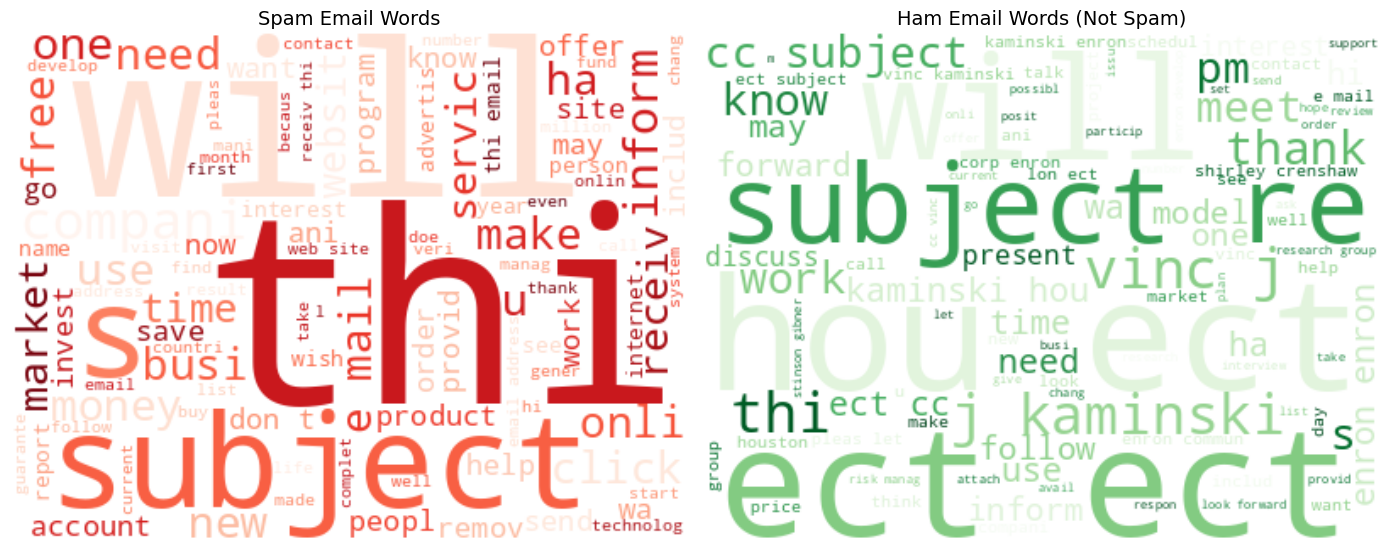

In [21]:
# Step 14: WordCloud visualizations (Bonus)
print("\n🔄 Generating WordCloud visualizations...")

# Separate spam and ham emails
spam_text = ' '.join(df[df['spam'] == 1]['clean_text'])
ham_text = ' '.join(df[df['spam'] == 0]['clean_text'])

plt.figure(figsize=(14,6))

# Spam WordCloud
plt.subplot(1,2,1)
wordcloud_spam = WordCloud(width=400, height=300, background_color='white', colormap='Reds', max_words=100).generate(spam_text)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Spam Email Words', fontsize=14)
plt.axis('off')

# Ham WordCloud
plt.subplot(1,2,2)
wordcloud_ham = WordCloud(width=400, height=300, background_color='white', colormap='Greens', max_words=100).generate(ham_text)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Ham Email Words (Not Spam)', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Step 15: Discussion - Why recall is important for spam detection
print("\n" + "="*70)
print("📝 IMPORTANT: Why RECALL matters for Email Spam Detection")
print("="*70)
print("""
Recall = TP / (TP + FN)

- High recall means: Most spam emails are caught
- Low recall means: Many spam emails go to your inbox (BAD!)
- False Negatives (spam labeled as ham) are MORE HARMFUL
- Than False Positives (ham labeled as spam)

Example:
- If recall = 0.95, then 95% of spam is caught
- If recall = 0.70, then 30% of spam reaches the inbox (unacceptable!)

✅ Our best model has recall: {:.4f}
""".format(results[best_model_name]['Recall']))


📝 IMPORTANT: Why RECALL matters for Email Spam Detection

Recall = TP / (TP + FN)

- High recall means: Most spam emails are caught
- Low recall means: Many spam emails go to your inbox (BAD!)
- False Negatives (spam labeled as ham) are MORE HARMFUL
- Than False Positives (ham labeled as spam)

Example:
- If recall = 0.95, then 95% of spam is caught
- If recall = 0.70, then 30% of spam reaches the inbox (unacceptable!)

✅ Our best model has recall: 0.9690



In [23]:
# Step 16: Sample predictions
print("\n📊 Sample Predictions (10 random emails):")
sample_indices = np.random.choice(len(X_test), 10, replace=False)
for idx in sample_indices:
    pred = best_model.predict(X_test[idx].reshape(1, -1))[0]
    actual = y_test[idx]
    pred_label = 'Spam' if pred == 1 else 'Ham'
    actual_label = 'Spam' if actual == 1 else 'Ham'
    status = '✅ Correct' if pred == actual else '❌ Wrong'
    print(f"   {status} | Predicted: {pred_label:5} | Actual: {actual_label:5}")


📊 Sample Predictions (10 random emails):
   ✅ Correct | Predicted: Ham   | Actual: Ham  
   ✅ Correct | Predicted: Spam  | Actual: Spam 
   ✅ Correct | Predicted: Spam  | Actual: Spam 
   ✅ Correct | Predicted: Ham   | Actual: Ham  
   ✅ Correct | Predicted: Ham   | Actual: Ham  
   ✅ Correct | Predicted: Spam  | Actual: Spam 
   ✅ Correct | Predicted: Spam  | Actual: Spam 
   ✅ Correct | Predicted: Ham   | Actual: Ham  
   ✅ Correct | Predicted: Ham   | Actual: Ham  
   ✅ Correct | Predicted: Ham   | Actual: Ham  




```
# What is TF-IDF? (Feature Extraction)

TF-IDF stands for **Term Frequency - Inverse Document Frequency**.

## 1. Term Frequency (TF)
Measures how often a word appears in a document

`TF = (Number of times word appears in document) / (Total words in document)`

## 2. Inverse Document Frequency (IDF)
Measures how rare or common a word is across all documents

`IDF = log(Total documents / Number of documents containing the word)`

## 3. TF-IDF = TF * IDF

### Why is it useful?
- Common words like 'the', 'is', 'are' get low scores
- Important/rare words get high scores
- Helps identify distinguishing words for classification

**Example**: In spam detection, words like 'free', 'viagra', 'click' get high TF-IDF scores because they appear frequently in spam but rarely in ham emails.
```



In [24]:
# Step 17: Summary
print("\n" + "="*70)
print("📊 EMAIL SPAM DETECTION - SUMMARY")
print("="*70)

print("\n1️⃣ Dataset Information:")
print(f"   - Total emails: {len(df)}")
print(f"   - Spam emails: {df['spam'].value_counts()[1]}")
print(f"   - Ham emails: {df['spam'].value_counts()[0]}")
print(f"   - Spam percentage: {df['spam'].value_counts(normalize=True)[1]*100:.2f}%")

print("\n2️⃣ Model Performance:")
for name, metrics in results.items():
    print(f"   {name}: F1={metrics['F1']:.4f}, Recall={metrics['Recall']:.4f}")

print(f"\n3️⃣ Best Model: {best_model_name}")
print(f"   - Accuracy: {results[best_model_name]['Accuracy']:.4f}")
print(f"   - Precision: {results[best_model_name]['Precision']:.4f}")
print(f"   - Recall: {results[best_model_name]['Recall']:.4f}")
print(f"   - F1 Score: {results[best_model_name]['F1']:.4f}")

print("\n4️⃣ Key Insights:")
print(f"   - {best_model_name} performs best for email spam detection")
print("   - Recall is crucial for spam detection to minimize false negatives")
print("   - Common spam words include: 'free', 'click', 'call', 'money', 'viagra', 'save'")

print("\n" + "="*70)
print("✅ Email Spam Detection Analysis Complete!")
print("="*70)


📊 EMAIL SPAM DETECTION - SUMMARY

1️⃣ Dataset Information:
   - Total emails: 5728
   - Spam emails: 1368
   - Ham emails: 4360
   - Spam percentage: 23.88%

2️⃣ Model Performance:
   Multinomial Naive Bayes: F1=0.9741, Recall=0.9724
   Logistic Regression: F1=0.9574, Recall=0.9310
   SVM: F1=0.9791, Recall=0.9690

3️⃣ Best Model: SVM
   - Accuracy: 0.9895
   - Precision: 0.9894
   - Recall: 0.9690
   - F1 Score: 0.9791

4️⃣ Key Insights:
   - SVM performs best for email spam detection
   - Recall is crucial for spam detection to minimize false negatives
   - Common spam words include: 'free', 'click', 'call', 'money', 'viagra', 'save'

✅ Email Spam Detection Analysis Complete!
